# Medical Image Processing: Final Project
## Einar López Altamirano

# Task 3: 3D Image Segmentation

## Libraries

In [34]:
import pydicom
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from pathlib import Path
import itk
import ipywidgets as widgets

%matplotlib widget
from matplotlib.widgets import RectangleSelector
from IPython.display import display

from ipywidgets import interact, IntSlider

from scipy.ndimage import binary_fill_holes

import matplotlib.lines as mlines

## Task 3A: Manual Tumor Segmentation


### PET And Transform Registration File Import

In [2]:
LAST_FRAME_PET_PATH = "./data/processed/last_frame_pet.mha"
REGISTRATION_TRANSFORM_PATH = "./data/processed/registration_transform.txt"

MR_PATH  = Path('data/15252129_s1_AX_3D_T1__C_FSPGR_FORISI260916')
mr_itk = itk.imread(str(MR_PATH), itk.F)

pet_last_frame_itk = itk.imread(str(LAST_FRAME_PET_PATH), itk.F)

registration_transform = itk.ParameterObject.New()
registration_transform.AddParameterFile(REGISTRATION_TRANSFORM_PATH)




### Transformation

In [3]:
pet_last_frame_registered = itk.transformix_filter(pet_last_frame_itk, 
                                                   transform_parameter_object=registration_transform)

### Sanity Check

In [4]:
print(itk.array_from_image(pet_last_frame_registered).shape)  
print(pet_last_frame_registered.GetSpacing())                

(156, 256, 256)
itkVectorD3 ([1, 1, 1])


### Manual Tumor Inspection

Label(value='BOX  z:[41, 97]  y:[155, 205]  x:[145, 195]')

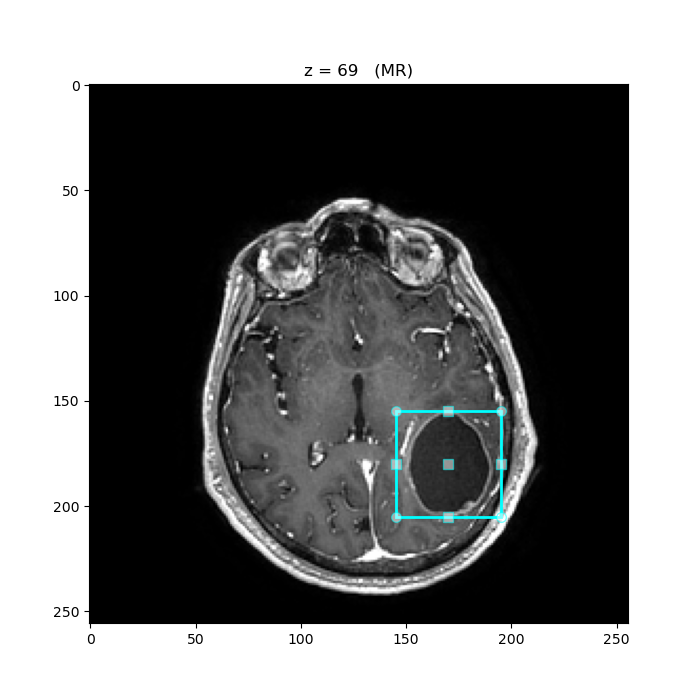

In [5]:
pet_vol = itk.array_from_image(pet_last_frame_registered)  
mr_vol  = itk.array_from_image(mr_itk)
nz, ny, nx = mr_vol.shape
mr_vmax  = np.percentile(mr_vol,  99.5)
pet_vmax = np.percentile(pet_vol, 99.5)

# Initial Estimation Coordinates
bbox = {'z_min': 41, 'z_max': 97, 'y_min': 155, 'y_max': 205, 'x_min': 145, 'x_max': 195}

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(mr_vol[nz // 2], cmap='gray', vmin=0, vmax=mr_vmax)

z_slider = widgets.IntSlider(min=0, max=nz - 1,
                             value=(bbox['z_min'] + bbox['z_max']) // 2, description='z')
img_pick = widgets.Dropdown(options=['MR', 'PET'], value='MR', description='image')
btn_zmin = widgets.Button(description='Mark z-min')
btn_zmax = widgets.Button(description='Mark z-max')
label    = widgets.Label()

def update_label():
    label.value = (f"BOX  z:[{bbox['z_min']}, {bbox['z_max']}]  "
                   f"y:[{bbox['y_min']}, {bbox['y_max']}]  x:[{bbox['x_min']}, {bbox['x_max']}]")

def redraw(*_):
    z = z_slider.value
    if img_pick.value == 'MR':
        im.set_data(mr_vol[z]);  im.set_cmap('gray'); im.set_clim(0, mr_vmax)
    else:
        im.set_data(pet_vol[z]); im.set_cmap('hot');  im.set_clim(0, pet_vmax)
    ax.set_title(f'z = {z}   ({img_pick.value})')
    fig.canvas.draw_idle()

def on_select(eclick, erelease):
    x0, x1 = sorted([eclick.xdata, erelease.xdata])
    y0, y1 = sorted([eclick.ydata, erelease.ydata])
    bbox['x_min'] = int(np.clip(round(x0), 0, nx - 1))
    bbox['x_max'] = int(np.clip(round(x1), 0, nx - 1))
    bbox['y_min'] = int(np.clip(round(y0), 0, ny - 1))
    bbox['y_max'] = int(np.clip(round(y1), 0, ny - 1))
    update_label()

selector = RectangleSelector(ax, on_select, useblit=True, button=[1], interactive=True,
                             props=dict(edgecolor='cyan', fill=False, linewidth=2))
selector.extents = (bbox['x_min'], bbox['x_max'], bbox['y_min'], bbox['y_max'])

z_slider.observe(redraw, names='value')
img_pick.observe(redraw, names='value')
btn_zmin.on_click(lambda _: (bbox.__setitem__('z_min', z_slider.value), update_label()))
btn_zmax.on_click(lambda _: (bbox.__setitem__('z_max', z_slider.value), update_label()))

redraw(); update_label()
display(widgets.HBox([z_slider, img_pick]), widgets.HBox([btn_zmin, btn_zmax]), label)

In [6]:
bbox_tumor = bbox
print(bbox_tumor)

{'z_min': 43, 'z_max': 97, 'y_min': 155, 'y_max': 201, 'x_min': 153, 'x_max': 189}


### Selected Coordinates
``{'z_min': 43, 'z_max': 97, 'y_min': 155, 'y_max': 201, 'x_min': 153, 'x_max': 189}``

``center: (z=69, y=179, x=170)``

### Export Registered MR For Segmentation Model

In [7]:
itk.imwrite(mr_itk, 'data/processed/mr.nii.gz')

### Sanity Check For .nii.gz File

In [8]:
check = itk.imread('data/processed/mr.nii.gz')
print(check.GetLargestPossibleRegion().GetSize(), check.GetSpacing())

itkSize3 ([256, 256, 156]) itkVectorD3 ([1, 1, 1])


## Task 3C: Segmented Tumor Mask Visualization and Assessment


### Import Tumor Segmentation Mask Generated In Colab


In [10]:
tumor_mask_itk = itk.imread('data/processed/tumor_mask.nii.gz')

### Dynamic Tumor Mask Visualization

In [11]:
mr_vol   = itk.array_from_image(mr_itk)
pet_vol  = itk.array_from_image(pet_last_frame_registered)
tumor_mask_vol = itk.array_from_image(tumor_mask_itk).astype(bool)
nz, ny, nx = mr_vol.shape

mr_vmax  = np.percentile(mr_vol,  99.5)
pet_vmax = np.percentile(pet_vol, 99.5)

def show(z):
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    axes[0].imshow(mr_vol[z],  cmap='gray', vmin=0, vmax=mr_vmax)
    axes[1].imshow(pet_vol[z], cmap='hot',  vmin=0, vmax=pet_vmax)
    if tumor_mask_vol[z].any():
        axes[0].contour(tumor_mask_vol[z], colors='cyan', linewidths=1.5)
        axes[1].contour(tumor_mask_vol[z], colors='cyan', linewidths=1.5)
    axes[0].set_title(f'MR + mask — z = {z}')
    axes[1].set_title(f'PET + mask — z = {z}')
    for ax in axes: ax.axis('off')
    plt.tight_layout(); plt.show()

interact(show, z=IntSlider(min=0, max=nz - 1, value=68, step=1, description='z'));

interactive(children=(IntSlider(value=68, description='z', max=155), Output()), _dom_classes=('widget-interact…

### Static Tumor Mask Visualization

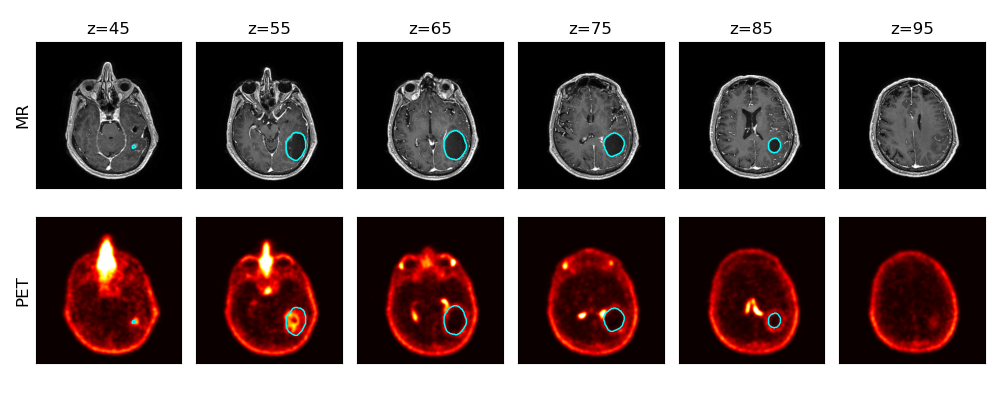

In [12]:
zs = list(range(45, 96, 10))
fig, axes = plt.subplots(2, len(zs), figsize=( 10, 4))
for col, z in enumerate(zs):
    axes[0, col].imshow(mr_vol[z],  cmap='gray', vmin=0, vmax=mr_vmax)
    axes[1, col].imshow(pet_vol[z], cmap='hot',  vmin=0, vmax=pet_vmax)
    for row in (0, 1):
        if tumor_mask_vol[z].any():
            axes[row, col].contour(tumor_mask_vol[z], colors='cyan', linewidths=1)
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
    axes[0, col].set_title(f'z={z}')
axes[0, 0].set_ylabel('MR',  fontsize=12)
axes[1, 0].set_ylabel('PET', fontsize=12)
plt.tight_layout()
plt.savefig('./results_task3/segmentation_overlay.png', dpi=120, bbox_inches='tight')
plt.show()

## Task 3C: Segmented Tumor Mask Visualization and Assessment

### Technique 1: Binary Fill Holes

#### Threshold Sweep

In [33]:
ai_mask = itk.array_from_image(tumor_mask_itk).astype(bool)
pet_arr = itk.array_from_image(pet_last_frame_registered)

# Define ROI
bbox = {'z_min': 43, 'z_max': 97, 'y_min': 155, 'y_max': 201, 'x_min': 153, 'x_max': 189}

box_mask = np.zeros_like(pet_arr, dtype=bool)
box_mask[bbox['z_min']:bbox['z_max'],
         bbox['y_min']:bbox['y_max'],
         bbox['x_min']:bbox['x_max']] = True

in_box_max    = pet_arr[box_mask].max()

spacing = mr_itk.GetSpacing()
voxel_volume_mm3 = float(spacing[0] * spacing[1] * spacing[2])

print(f'{"Threshold (% of in-box max)":>27s}  {"Threshold value (PET units)":>27s}  {"Reference voxels":>16s}  {"Reference volume (cm³)":>22s}  {"Dice":>6s}  {"Precision":>9s}  {"Recall":>6s}')

print('-' * 130)

for pct in [ 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]:
    thr = pct * in_box_max
    ref = binary_fill_holes((pet_arr >= thr) & box_mask)
    n  = int(ref.sum())
    vol = n * voxel_volume_mm3 / 1000
    tp = int(np.logical_and(ai_mask, ref).sum())
    ai_n = int(ai_mask.sum())
    d = 2*tp / (ai_n + n) if (ai_n + n) else 0
    p = tp / ai_n         if ai_n else 0
    r = tp / n            if n else 0
    
    print(f'{pct*100:>25.0f} %  {thr:>27.1f}  {n:>16d}  {vol:>22.2f}  {d:>6.3f}  {p:>9.3f}  {r:>6.3f}')

Threshold (% of in-box max)  Threshold value (PET units)  Reference voxels  Reference volume (cm³)    Dice  Precision  Recall
----------------------------------------------------------------------------------------------------------------------------------
                       10 %                        153.9             59061                   59.06   0.430      0.509   0.373
                       15 %                        230.9             44504                   44.50   0.383      0.388   0.378
                       20 %                        307.9             32068                   32.07   0.348      0.303   0.409
                       25 %                        384.8             21598                   21.60   0.319      0.239   0.479
                       30 %                        461.8             14185                   14.19   0.274      0.182   0.556
                       35 %                        538.8             10204                   10.20   0.237      0

#### Threshold Sweep Visualization

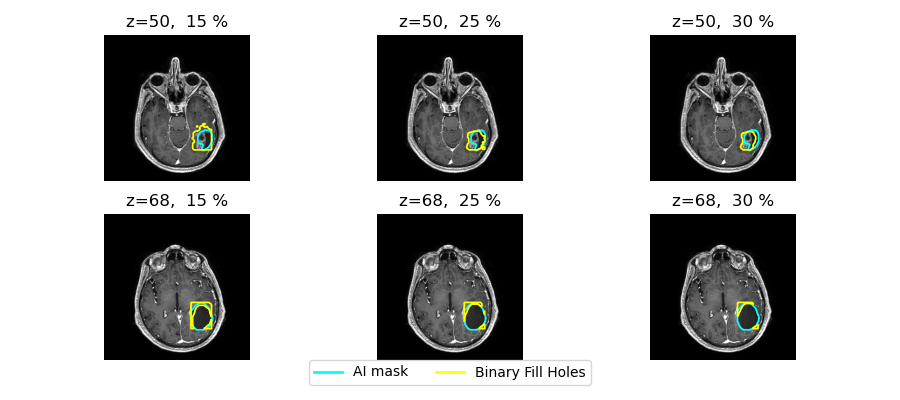

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(9, 4))
for row, z in enumerate([50, 68]):
    for col, pct in enumerate([0.15, 0.25, 0.30]):
        thr = pct * in_box_max
        ref = binary_fill_holes((pet_arr >= thr) & box_mask)
        ax = axes[row, col]
        ax.imshow(mr_vol[z], cmap='gray', vmin=0, vmax=mr_vmax)
        if ai_mask[z].any(): ax.contour(ai_mask[z], colors='cyan',   linewidths=1.2)
        if ref[z].any():     ax.contour(ref[z],     colors='yellow', linewidths=1.2)
        ax.set_title(f'z={z},  {pct*100:.0f} %')
        ax.axis('off')

    handles = [
    mlines.Line2D([], [], color='cyan',   lw=2, label='AI mask'),
    mlines.Line2D([], [], color='yellow', lw=2, label='Binary Fill Holes'),
    ]  
fig.legend(handles=handles, loc='lower center', ncol=2, bbox_to_anchor=(0.5, 0.02))
plt.tight_layout()
plt.subplots_adjust(bottom=0.10)  
plt.show()

#### Threshold Sweep

#### Selected Threshold Detailed Results

In [26]:
threshold_pct = 0.3
in_box_max    = pet_arr[box_mask].max()
threshold     = threshold_pct * in_box_max
pet_thresh    = (pet_arr >= threshold) & box_mask

pet_ref = binary_fill_holes(pet_thresh)

print(f'Threshold ({threshold_pct:.0%} of in-box max): {threshold:.1f}')
print(f'PET reference voxels: {int(pet_ref.sum())}')
print(f'AI mask voxels:       {int(ai_mask.sum())}')

tp = int(np.logical_and(ai_mask, pet_ref).sum())
ai_size = int(ai_mask.sum())
ref_size = int(pet_ref.sum())
union = int(np.logical_or(ai_mask, pet_ref).sum())

dice = 2 * tp / (ai_size + ref_size)
iou = tp / union
precision = tp / ai_size               # over-segmentation hits this
recall = tp / ref_size              # under-segmentation hits this

ai_vol_cm3  = ai_size  * voxel_volume_mm3 / 1000
ref_vol_cm3 = ref_size * voxel_volume_mm3 / 1000

def centroid(mask):
    zs, ys, xs = np.where(mask)
    return np.array([zs.mean(), ys.mean(), xs.mean()])

sx, sy, sz = spacing
c_ai, c_ref = centroid(ai_mask), centroid(pet_ref)
dist_mm = float(np.linalg.norm((c_ai - c_ref) * np.array([sz, sy, sx])))

print()
print(f'Dice            : {dice:.3f}')
print(f'IoU             : {iou:.3f}')
print(f'Precision       : {precision:.3f}')
print(f'Recall          : {recall:.3f}')
print(f'AI volume       : {ai_vol_cm3:.2f} cm³')
print(f'PET ref volume  : {ref_vol_cm3:.2f} cm³')
print(f'Volume diff     : {ai_vol_cm3 - ref_vol_cm3:+.2f} cm³  ({100*(ai_vol_cm3/ref_vol_cm3 - 1):+.1f} %)')
print(f'Centroid dist   : {dist_mm:.2f} mm')

Threshold (30% of in-box max): 461.8
PET reference voxels: 14185
AI mask voxels:       43267

Dice            : 0.274
IoU             : 0.159
Precision       : 0.182
Recall          : 0.556
AI volume       : 43.27 cm³
PET ref volume  : 14.19 cm³
Volume diff     : +29.08 cm³  (+205.0 %)
Centroid dist   : 8.08 mm


#### Selected Threshold Dynamic Visulization

In [ ]:
mr_arr   = itk.array_from_image(mr_itk)
mr_vmax  = np.percentile(mr_arr,  99.5)
pet_vmax = np.percentile(pet_arr, 99.5)


def show(z):
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    axes[0].imshow(mr_arr[z],  cmap='gray', vmin=0, vmax=mr_vmax)
    axes[1].imshow(pet_arr[z], cmap='gray',  vmin=0, vmax=pet_vmax)
    for ax in axes:
        if ai_mask[z].any(): ax.contour(ai_mask[z], colors='cyan',   linewidths=1.5)
        if pet_ref[z].any(): ax.contour(pet_ref[z], colors='yellow', linewidths=1.5)
        ax.axis('off')
    axes[0].set_title(f'MR  —  cyan = AI mask,  yellow = PET ref  (z={z})')
    axes[1].set_title(f'PET  —  cyan = AI mask,  yellow = PET ref  (z={z})')
    plt.tight_layout()
    plt.savefig('./results_task3/mask_vs_reference.png', dpi=120, bbox_inches='tight')
    plt.show()

interact(show, z=IntSlider(min=0, max=nz - 1, value=68, step=1, description='z'));



interactive(children=(IntSlider(value=68, description='z', max=155), Output()), _dom_classes=('widget-interact…

### Technique 2: Manual Annotation

In [30]:
manual_mask_itk = itk.imread('data/processed/manual_mask.nii.gz')
manual_mask = itk.array_from_image(manual_mask_itk).astype(bool)

print('manual_mask shape:', manual_mask.shape)
print('manual_mask voxels:', int(manual_mask.sum()))
print('AI mask voxels    :', int(ai_mask.sum()))

manual_mask shape: (156, 256, 256)
manual_mask voxels: 43096
AI mask voxels    : 43267


In [31]:
ai_mask = itk.array_from_image(tumor_mask_itk).astype(bool)
ref     = manual_mask

tp = int(np.logical_and(ai_mask, ref).sum())
ai_size  = int(ai_mask.sum())
ref_size = int(ref.sum())
union    = int(np.logical_or(ai_mask, ref).sum())

dice      = 2*tp / (ai_size + ref_size)
iou       = tp / union
precision = tp / ai_size
recall    = tp / ref_size

spacing = mr_itk.GetSpacing()
voxel_volume_mm3 = float(spacing[0]*spacing[1]*spacing[2])
ai_vol_cm3  = ai_size  * voxel_volume_mm3 / 1000
ref_vol_cm3 = ref_size * voxel_volume_mm3 / 1000

def centroid(mask):
    zs, ys, xs = np.where(mask); return np.array([zs.mean(), ys.mean(), xs.mean()])

sx, sy, sz = spacing
dist_mm = float(np.linalg.norm((centroid(ai_mask) - centroid(ref)) * np.array([sz, sy, sx])))

print(f'Dice            : {dice:.3f}')
print(f'IoU             : {iou:.3f}')
print(f'Precision       : {precision:.3f}')
print(f'Recall          : {recall:.3f}')
print(f'AI volume       : {ai_vol_cm3:.2f} cm³')
print(f'Manual volume   : {ref_vol_cm3:.2f} cm³')
print(f'Volume diff     : {ai_vol_cm3 - ref_vol_cm3:+.2f} cm³  ({100*(ai_vol_cm3/ref_vol_cm3 - 1):+.1f} %)')
print(f'Centroid dist   : {dist_mm:.2f} mm')

Dice            : 0.927
IoU             : 0.865
Precision       : 0.926
Recall          : 0.929
AI volume       : 43.27 cm³
Manual volume   : 43.10 cm³
Volume diff     : +0.17 cm³  (+0.4 %)
Centroid dist   : 1.36 mm


In [ ]:
def show(z):
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    axes[0].imshow(mr_vol[z],  cmap='gray', vmin=0, vmax=mr_vmax)
    axes[1].imshow(pet_vol[z], cmap='hot',  vmin=0, vmax=pet_vmax)
    for ax in axes:
        if ai_mask[z].any():     ax.contour(ai_mask[z],     colors='cyan',   linewidths=1.5)
        if manual_mask[z].any(): ax.contour(manual_mask[z], colors='yellow', linewidths=1.5)
        ax.axis('off')
    axes[0].set_title(f'MR  —  cyan = AI,  yellow = manual  (z={z})')
    axes[1].set_title(f'PET — cyan = AI,  yellow = manual  (z={z})')
    

    plt.tight_layout()
    plt.savefig('./results_task3/mask_vs_manual.png', dpi=120, bbox_inches='tight')
    plt.show()

interact(show, z=IntSlider(min=0, max=nz-1, value=68, step=1, description='z'));

interactive(children=(IntSlider(value=68, description='z', max=155), Output()), _dom_classes=('widget-interact…

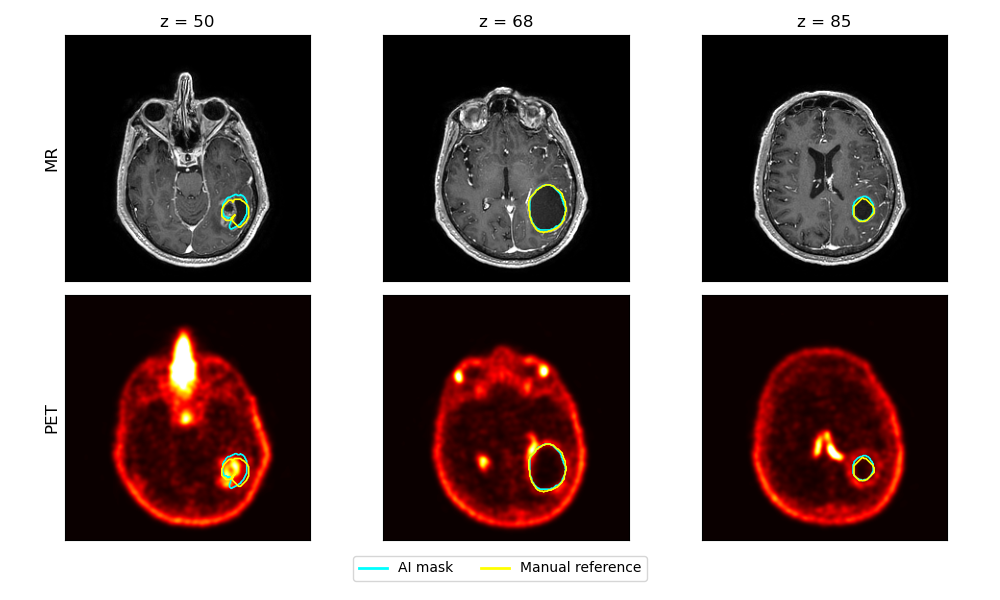

In [ ]:
mr_arr  = itk.array_from_image(mr_itk)
pet_arr = itk.array_from_image(pet_last_frame_registered)

mr_vmax  = np.percentile(mr_arr,  99.5)
pet_vmax = np.percentile(pet_arr, 99.5)

zs = [50, 68, 85] 

fig, axes = plt.subplots(2, len(zs), figsize=(10, 6))

for col, z in enumerate(zs):
    axes[0, col].imshow(mr_arr[z],  cmap='gray', vmin=0, vmax=mr_vmax)
    axes[1, col].imshow(pet_arr[z], cmap='hot',  vmin=0, vmax=pet_vmax)
    for row in (0, 1):
        ax = axes[row, col]
        if ai_mask[z].any():     ax.contour(ai_mask[z],     colors='cyan',   linewidths=1.2)
        if manual_mask[z].any(): ax.contour(manual_mask[z], colors='yellow', linewidths=1.2)
        ax.set_xticks([]); ax.set_yticks([])
    axes[0, col].set_title(f'z = {z}')

axes[0, 0].set_ylabel('MR',  fontsize=12)
axes[1, 0].set_ylabel('PET', fontsize=12)

handles = [
    mlines.Line2D([], [], color='cyan',   lw=2, label='AI mask'),
    mlines.Line2D([], [], color='yellow', lw=2, label='Manual reference'),
]
fig.legend(handles=handles, loc='lower center', ncol=2, bbox_to_anchor=(0.5, 0.02))

plt.tight_layout()
plt.subplots_adjust(bottom=0.10)           
plt.savefig('./results_task3/mask_vs_manual_static.png', dpi=120, bbox_inches='tight')
plt.show()